# EdinburghAI: TinyML E-Nose

# Setup python environment

In [61]:
# Setup environment
%pip install pandas numpy matplotlib ai-edge-litert tensorflow seaborn

Note: you may need to restart the kernel to use updated packages.


# Load Data

In [94]:
import pandas as pd
import os

dfs = []
for file in os.listdir("../data"):
    if not file.endswith(".csv"):
        continue

    if file == "lavender.csv": continue

    df = pd.read_csv(f"../data/{file}")
    df["smell"] = file[:-4]
    dfs.append(df)

NUM_CLASSES = len(dfs)

data = pd.concat(dfs)
print(len(data), "entries")
data.head()

56737 entries


,Unnamed: 0,id_timestamp,id_index,sensor_index,sensor_id,timestamp_since_poweron,real_time_clock,temperature,pressure,relative_humidity,resistance_gassensor,heater_profile_step_index,scanning_enabled,scanning_cycle_index,label_tag,error_code,smell
0,0.0,2026_02_19_18_16,0,0,1724206365,6374,1771525018,23.645849,999.777771,40.639824,27789.839844,0,1,1,0,0,eucalyptus
1,1.0,2026_02_19_18_16,1,1,1724192798,6379,1771525018,23.849823,1000.026123,40.125591,23738.873047,0,1,1,0,0,eucalyptus
2,2.0,2026_02_19_18_16,2,2,1724204062,6383,1771525018,23.891716,999.956726,40.236500,27118.644531,0,1,1,0,0,eucalyptus
3,3.0,2026_02_19_18_16,3,3,1724221471,6388,1771525018,23.809145,999.833679,39.868423,26879.462891,0,1,1,0,0,eucalyptus
4,4.0,2026_02_19_18_16,4,4,1724209694,6392,1771525018,23.972052,999.788818,38.633560,25256.511719,0,1,1,0,0,eucalyptus


# Graph Data

<Figure size 800x600 with 0 Axes>

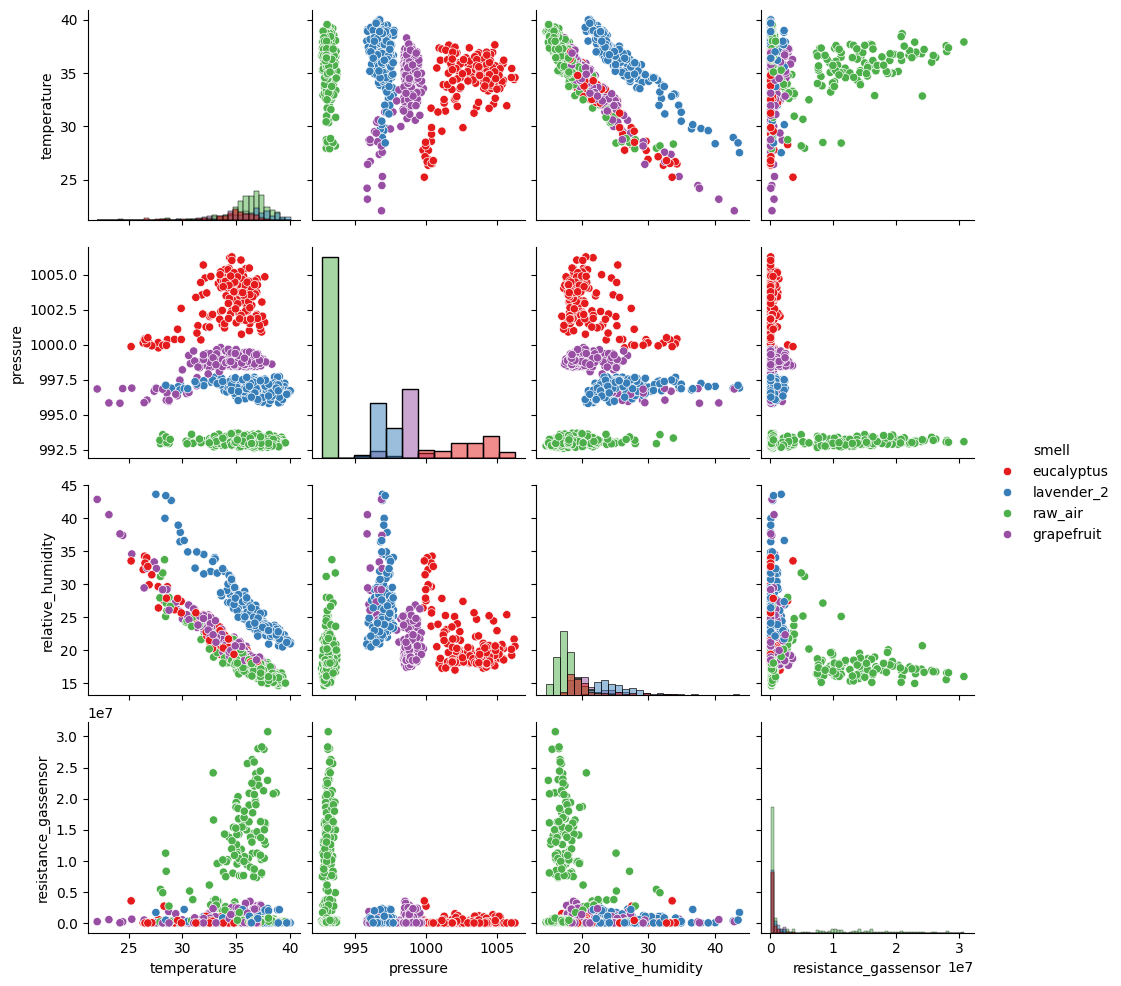

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

FEATURE_COLS = ["temperature", "pressure", "relative_humidity", "resistance_gassensor"]
TARGET_COL = "smell"

plt.figure(figsize=(8,6))

datas = data.sample(n=1000)  # sample so it doesn't take 10 years
sns.pairplot(datas[FEATURE_COLS+[TARGET_COL]], hue=TARGET_COL, palette='Set1', diag_kind='hist')
plt.show()


# Train Neural Network

## Split data into training and testing

In [78]:
TESTING_RATIO = 0.9

training_data = data.sample(frac=(1-TESTING_RATIO), random_state=67)
testing_data = data.drop(training_data.index)

print(f"{len(training_data)} training : {len(testing_data)} testing samples")

5674 training : 41040 testing samples


## Data Preprocessing

In [80]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

x_train = training_data[FEATURE_COLS]
y_train = training_data[TARGET_COL]

x_test = testing_data[FEATURE_COLS]
y_test = testing_data[TARGET_COL]


label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train[:, 3] = np.log1p(x_train[:, 3])
x_test[:, 3] = np.log1p(x_test[:, 3])

## Build model

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Input

model = Sequential()

model.add(Input(shape=(4,)))

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(NUM_CLASSES, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 420 (1.64 KB)

 Trainable params: 420 (1.64 KB)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [82]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    x_train,
    y_train_enc,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5200 - loss: 1.0966 - val_accuracy: 0.6602 - val_loss: 0.8300
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6555 - loss: 0.7982 - val_accuracy: 0.8116 - val_loss: 0.5648
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7791 - loss: 0.5599 - val_accuracy: 0.8768 - val_loss: 0.3493
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8631 - loss: 0.3863 - val_accuracy: 0.9595 - val_loss: 0.2257
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9162 - loss: 0.2788 - val_accuracy: 0.9894 - val_loss: 0.1594
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9303 - loss: 0.2242 - val_accuracy: 0.9982 - val_loss: 0.1115
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9487 - loss: 0.1757 - val_accuracy: 1.0000 - val_loss: 0.0788
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9516 - loss: 0.1457 - val_accuracy: 0.9982 - val_loss:

## Graph the loss

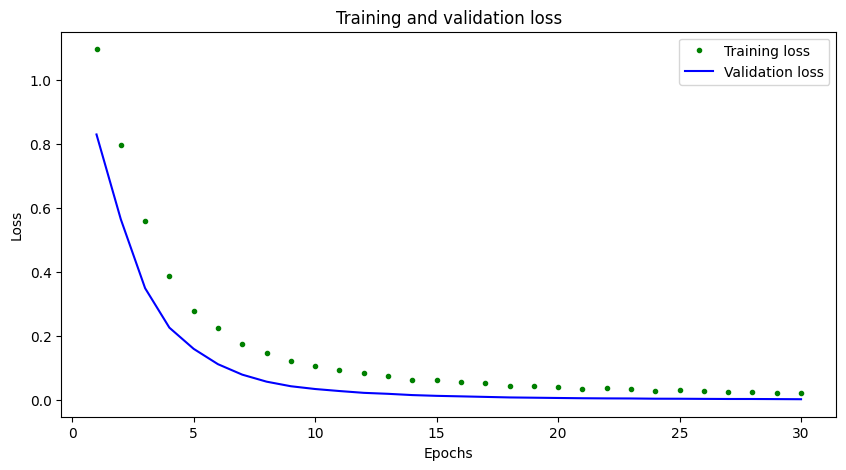

[10.0, 5.0]


In [83]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,5)

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'g.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(plt.rcParams["figure.figsize"])

# Run with test data

In [84]:
test_loss, test_acc = model.evaluate(x_test, y_test_enc)
print("Test accuracy:", test_acc)

1283/1283 ━━━━━━━━━━━━━━━━━━━━ 1s 632us/step - accuracy: 0.9999 - loss: 0.0020
Test accuracy: 0.9999269247055054


# Convert to litert model

In [98]:
import tensorflow as tf
import os

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # quantization
tflite_model = converter.convert()

with open('model.tflite', 'wb') as f:
  f.write(tflite_model)

basic_model_size = os.path.getsize("model.tflite")
print("Model is %d bytes" % basic_model_size)

INFO:tensorflow:Assets written to: C:\Users\james\AppData\Local\Temp\tmp1dzz8z0j\assets


INFO:tensorflow:Assets written to: C:\Users\james\AppData\Local\Temp\tmp1dzz8z0j\assets


Saved artifact at 'C:\Users\james\AppData\Local\Temp\tmp1dzz8z0j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor_91')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2560275468688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2560653516368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2560653513104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2560347891920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2560275465808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2560275467728: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model is 3832 bytes


## Test litert model

In [99]:
from ai_edge_litert.compiled_model import CompiledModel

model_lite = CompiledModel.from_file("model.tflite")

signature_index = 0

input_buffers = model_lite.create_input_buffers(signature_index)
output_buffers = model_lite.create_output_buffers(signature_index)


n_correct = 0

for i in range(len(x_test)):
    input_data = np.float32(x_test[i])
    input_buffers[0].write(input_data)

    model_lite.run_by_index(signature_index, input_buffers, output_buffers)
    output_array = output_buffers[0].read(NUM_CLASSES, np.float32)

    pred_class = int(np.argmax(output_array))
    true_class = int(y_test_enc[i])

    if pred_class == true_class:
        n_correct += 1

print("LiteRT accuracy:", n_correct / len(x_test))

LiteRT accuracy: 0.9999269005847953


## Encode the model in an arduino header file

In [100]:
import os

os.system("""
echo "const unsigned char model[] = {" > /content/model.h
cat model.tflite | xxd -i      >> /content/model.h
echo "};"                              >> /content/model.h
""")

model_h_size = os.path.getsize("model.h")
print(f"Header file, model.h, is {model_h_size:,} bytes.")

Header file, model.h, is 23,278 bytes.
